### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
# Imports 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from scipy.stats import multivariate_normal

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

In [2]:
# Data Generation
np.random.seed(0)

def gen_data(N, eps, p):
    mu0, mu1 = np.array([0, 0]), np.array([eps, 0])
    sig0, sig1 = np.array([[0.5, 0],[0, 0.5]]), np.array([[0.4, 0],[0, 0.4]])
    U = np.random.rand(N)
    X = np.zeros((N, 2))
    y = (U < p).astype(int)
    X[y == 0] = np.random.multivariate_normal(mu0, sig0, size=np.sum(y == 0))
    X[y == 1] = np.random.multivariate_normal(mu1, sig1, size=np.sum(y == 1))
    return X, y

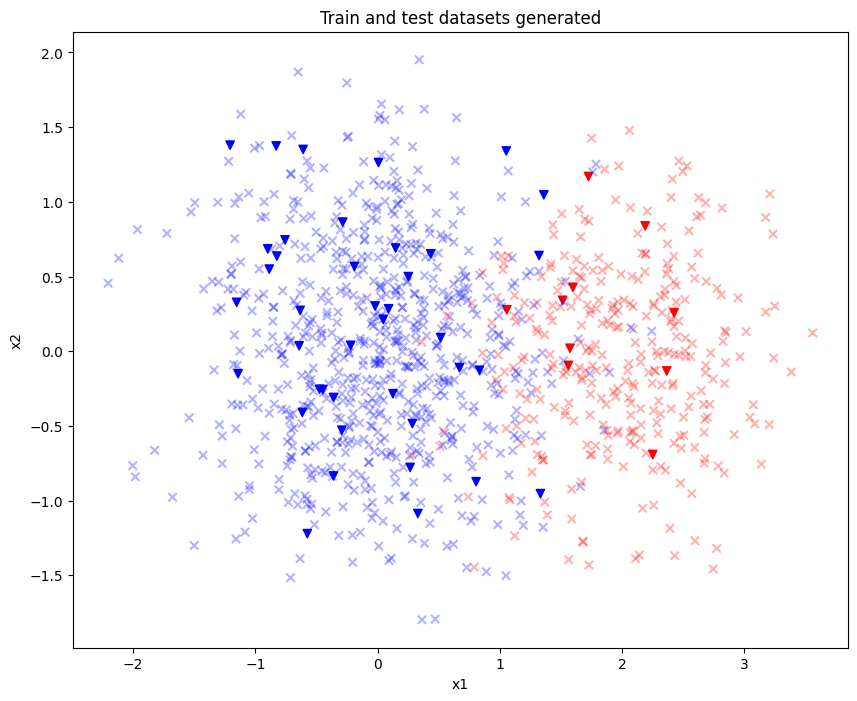

In [3]:
X_train, y_train = gen_data(50, 2, 0.30)
X_test, y_test = gen_data(1000, 2, 0.30)

# Data Plot
plt.figure(figsize=(10,8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', marker='v')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', marker='x', alpha=0.3)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title("Train and test datasets generated")
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal Bayes classifier assigns an observation to the class that maximizes the posterior probability $\text{Prob}(Y = k \mid \mathbf{x})$. The decision rule can be written as a ratio. We predict class 1 if and only if the ratio of the posterior probabilities is strictly greater than 1.
$$\frac{\text{Prob}(Y = 1 \mid \mathbf{x})}{\text{Prob}(Y = 0 \mid \mathbf{x})} > 1$$

Using Bayes' theorem, we can rewrite each posterior probability. For a continuous neighborhood, the probability density function is evaluated such that the posterior is approximately equal to the likelihood multiplied by the prior, divided by the marginal probability.
$$\text{Prob}(Y = k \mid \mathbf{x}) \approx \frac{p(\mathbf{x} \mid Y = k)\text{Prob}(Y = k)}{p(\mathbf{x})}$$

Substituting this into our initial ratio, we have :
$$\frac{p(\mathbf{x} \mid Y = 1)\text{Prob}(Y = 1)}{p(\mathbf{x} \mid Y = 0)\text{Prob}(Y = 0)} > 1$$

Given that the priors are defined as Prob(Y = 1) = p and Prob(Y = 0) = 1 - p, we can substitute them to obtain the expression for the classifier's decision rule : 
$$\frac{p \cdot p(\mathbf{x} \mid Y = 1)}{(1-p) \cdot p(\mathbf{x} \mid Y = 0)} > 1$$

So the classifier is : 
$$f(\mathbf{x}) = \begin{cases} 
1 & \text{if } p \cdot p(\mathbf{x} \mid Y = 1) > (1-p) \cdot p(\mathbf{x} \mid Y = 0) \\ 
0 & \text{otherwise} 
\end{cases}$$

The boundary region is the set of points where the model is perfectly undecided, so where we have an equality. Since the conditional densities follow multivariate normal distributions, we replace them with the logarithm of the Gaussian density equation. This yields to this expression for the boundary region : 

$$\log\left(\frac{p}{1-p}\right) + \log p(\mathbf{x} \mid Y=1) - \log p(\mathbf{x} \mid Y=0) = 0$$

$$\log\left(\frac{p}{1-p}\right) - \frac{1}{2}\log\left(\frac{\det\boldsymbol{\Sigma}_1}{\det\boldsymbol{\Sigma}_0}\right) - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_1)^\top \boldsymbol{\Sigma}_1^{-1}(\mathbf{x}-\boldsymbol{\mu}_1) + \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_0)^\top \boldsymbol{\Sigma}_0^{-1}(\mathbf{x}-\boldsymbol{\mu}_0) = 0$$

As highlighted in the TD5, because the covariance matrices are not equal for the two classes, the quadratic terms involving the inverse covariance matrices do not cancel each other out. Consequently, we have a quadratic decision boundary rather than a linear one. So a generative approach like Quadratic Discriminant Analysis (QDA) is perfectly suited for these data.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

**Answer (c) :** Since the classifier already knows the true generative parameters, the fit method does not need to learn anything. The predict method calculates the posterior probabilities using the true means and covariance matrices. 

We would expect the error to decrease when $\epsilon$ increases, because it means the *distance between the distribution means grows*, so the **classes become more separable**. The classification can work better, so the error rate drop to zero.

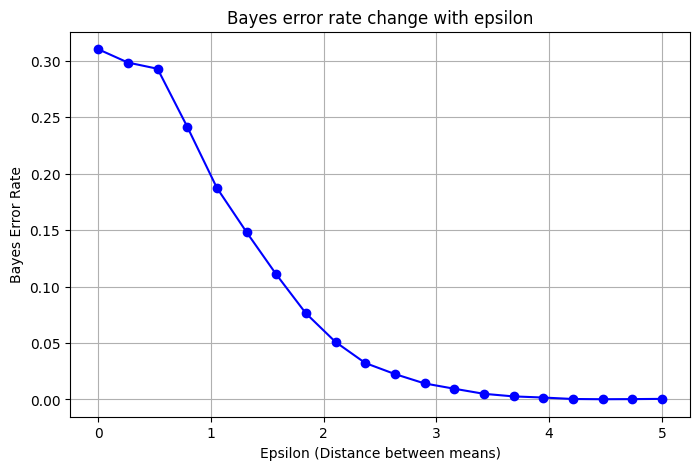

In [4]:
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, eps=2.0, p=0.3):
        self.eps = eps
        self.p = p
        self.mu0 = np.array([0, 0])
        self.mu1 = np.array([self.eps, 0])
        self.sig0 = np.array([[0.5, 0], [0, 0.5]])
        self.sig1 = np.array([[0.4, 0], [0, 0.4]])
        
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        prior_0 = 1 - self.p
        prior_1 = self.p
        
        lik_0 = multivariate_normal.pdf(X, mean=self.mu0, cov=self.sig0)
        lik_1 = multivariate_normal.pdf(X, mean=self.mu1, cov=self.sig1)
        
        post_0 = lik_0 * prior_0
        post_1 = lik_1 * prior_1
        
        return (post_1 > post_0).astype(int)

epsilons = np.linspace(0, 5, 20)
p = 0.3
errors = []

for eps in epsilons:
    X_test_large, y_test_large = gen_data(10000, eps, p)
    clf = BayesClassifier(eps=eps, p=p)
    y_pred = clf.predict(X_test_large)
    errors.append(1.0 - accuracy_score(y_test_large, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(epsilons, errors, marker='o', linestyle='-', color='b')
plt.xlabel('Epsilon (Distance between means)')
plt.ylabel('Bayes Error Rate')
plt.title('Bayes error rate change with epsilon')
plt.grid(True)
plt.show()

In [5]:
#for a train sample with 10000 points, eps = 2 and p=0.3

X_test_large, y_test_large = gen_data(10000, 2, 0.3)
clf = BayesClassifier(eps=2, p=p)
y_pred = clf.predict(X_test_large)

error = 1 - accuracy_score(y_test_large, y_pred)

print(f"Test error (Bayes Classifier) : {error:.4f}")


Test error (Bayes Classifier) : 0.0613


**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**Answer (d) :** The most adequate classifier presented in the lectures seems to be the **Quadratic Discriminant Analysis**, as seen in the TD5. The justification is that the data generation process simulates samples from multivariate normal distributions with **different covariance matrices** for each class. This exactly matches the generative assumptions behind QDA. Linear Discriminant Analysis incorrectly assumes that the covariance matrices are equal, which forces a suboptimal linear boundary. Logistic Regression models the log-odds directly as a linear combination, which also fails to capture the true quadratic nature of the boundary.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [6]:
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "LogReg": LogisticRegression()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Test Error ({name}): {1 - accuracy_score(y_test, y_pred):.4f}")

Test Error (LDA): 0.0670
Test Error (QDA): 0.0730
Test Error (LogReg): 0.0700


/tmp/ipykernel_1440368/1092674228.py:11: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=20, alpha=0.4, marker='x')
/tmp/ipykernel_1440368/1092674228.py:11: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=20, alpha=0.4, marker='x')
/tmp/ipykernel_1440368/1092674228.py:11: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=20, alpha=0.4, marker='x')


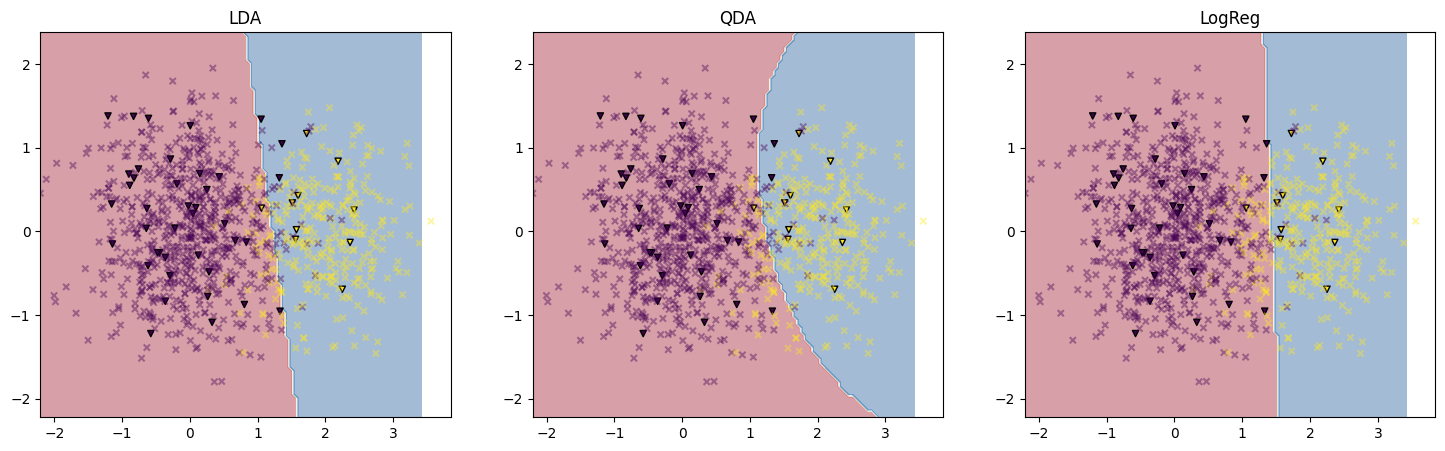

In [7]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, models.items()):
    DecisionBoundaryDisplay.from_estimator(
        clf, X_train, ax=ax, response_method="predict", alpha=0.4, cmap='RdBu'
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", s=20, marker='v')
    
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=20, alpha=0.4, marker='x')
    
    ax.set_title(name)

# plt.tight_layout()
# plt.show()

**Answer (e) :** While QDA is the best model for this setup, our training set is very small with only 50 samples. QDA has to estimate significantly more parameters than LDA or Logistic Regression because it computes two full covariance matrices, so the result isn't much more better for this size of training set. On such a small dataset, QDA suffers from **high variance** and tends to overfit, which results in a much higher test error compared to the value obtained in c (around 0.05). 

If we increase the number of training samples, the QDA test error would converge asymptotically to the error rate below. Meanwhile, LDA and Logistic Regression would maintain an irreducible bias because they are restricted to a linear boundary and cannot learn the true quadratic shape.

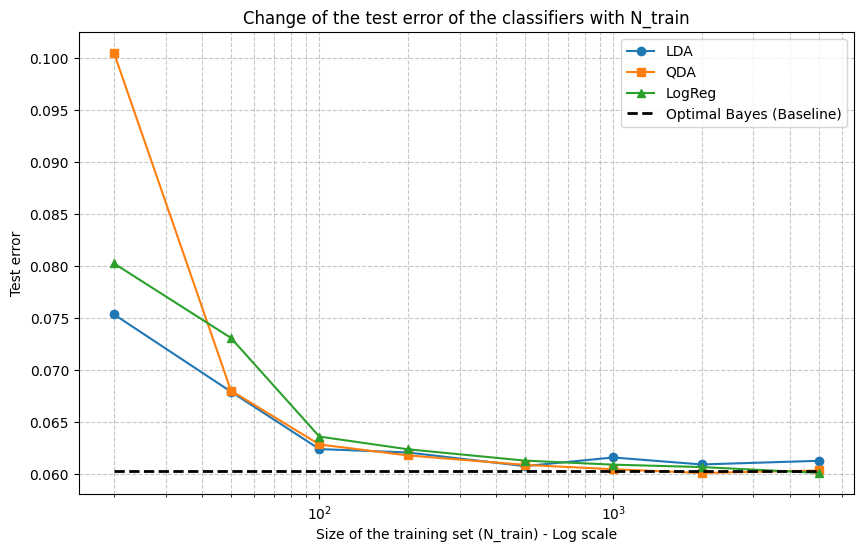

In [14]:
X_test_large, y_test_large = gen_data(10000, 2, 0.3)
train_sizes = [20, 50, 100, 200, 500, 1000, 2000, 5000]

errors_lda = []
errors_qda = []
errors_logreg = []
errors_bayes = []

# Bayes error, is constant with D_train, because there is no training
bayes_clf = BayesClassifier(eps=2.0, p=0.3)
bayes_pred = bayes_clf.predict(X_test_large)
bayes_error = 1.0 - accuracy_score(y_test_large, bayes_pred)

for n in train_sizes:
    errors_temp_lda = []
    errors_temp_qda = []
    errors_temp_logreg = []
    
    attempts = 0
    while len(errors_temp_qda) < 10 and attempts < 50:
        attempts += 1
        X_train, y_train = gen_data(n, 2, 0.3)
        
        if np.sum(y_train == 0) < 3 or np.sum(y_train == 1) < 3:
            continue 
            
        try:
            # LDA
            lda = LinearDiscriminantAnalysis()
            lda.fit(X_train, y_train)
            errors_temp_lda.append(1.0 - accuracy_score(y_test_large, lda.predict(X_test_large)))

            # QDA
            qda = QuadraticDiscriminantAnalysis() 
            qda.fit(X_train, y_train)
            errors_temp_qda.append(1.0 - accuracy_score(y_test_large, qda.predict(X_test_large)))
            
            # Logistic Regression
            logreg = LogisticRegression()
            logreg.fit(X_train, y_train)
            errors_temp_logreg.append(1.0 - accuracy_score(y_test_large, logreg.predict(X_test_large)))
        except:
            continue
            
    errors_lda.append(np.mean(errors_temp_lda))    
    errors_qda.append(np.mean(errors_temp_qda))    
    errors_logreg.append(np.mean(errors_temp_logreg))    
    errors_bayes.append(bayes_error)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, errors_lda, label='LDA', marker='o')
plt.plot(train_sizes, errors_qda, label='QDA', marker='s')
plt.plot(train_sizes, errors_logreg, label='LogReg', marker='^')
plt.plot(train_sizes, errors_bayes, label='Optimal Bayes (Baseline)', linestyle='--', color='black', linewidth=2)

plt.xscale('log')
plt.xlabel("Size of the training set (N_train) - Log scale")
plt.ylabel("Test error")
plt.title("Change of the test error of the classifiers with N_train")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.show()

When we evaluate the models over an increasing number of training samples, we observe a perfect illustration of the bias-variance trade-off and the asymptotic properties of the classifiers:

- **Optimal Bayes (Baseline)**: The black dashed line represents the irreducible error. Since the Bayes classifier operates with the true data distribution parameters, its error is constant regardless of the training size. It serves as the absolute lower bound.

- **QDA**: For very small training sets (e.g., N=20,50), QDA performs worse than the linear models. This is because QDA must estimate significantly more parameters (two full covariance matrices), leading to high variance and overfitting on small data. However, as N_train increases, QDA converges to the Optimal Bayes baseline. This is theoretically coherent because QDA shares the exact same generative assumptions as the true data distribution.

- **LDA and Logistic Regression**: These models perform reasonably well on small datasets because their simplicity (fewer parameters to estimate) protects them from high variance. However, because they are mathematically restricted to a linear decision boundary, they suffer from an irreducible model bias. As N_train grows large, they asymptotically fail to reach the Optimal Bayes baseline, ultimately getting outperformed by QDA once there is enough data to properly estimate the quadratic boundary.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [9]:
X_test_new, y_test_new = gen_data(1000, 0.5, 0.7)

for name, model in models.items():
    y_pred_new = model.predict(X_test_new)
    print(f"New Test Error ({name}): {1 - accuracy_score(y_test_new, y_pred_new):.4f}")

New Test Error (LDA): 0.6400
New Test Error (QDA): 0.6540
New Test Error (LogReg): 0.6750


**Answer (f) :** When testing the models on the new dataset, we observe a massive increase in the test error, which seems coherent. Indeed, the classifiers were trained in an environment where the classes were far apart and class 0 was the vast majority. In the new test set, the class means are much closer and class 1 is now the majority. The models apply decision rules and prior probabilities learned from training data generated with a very different model, which makes their predictions completely inaccurate for the new data distribution, even worse than random guessing.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

The feature engineering for this dataset was divided into a targeted manual extraction and an automated pipeline.

First, I manually extracted the passenger's title from the Name column using regular expressions to create a new categorical feature called Title. To reduce noise and prevent "unknown category" warnings during cross-validation, I grouped rare titles into a single 'Misc' category and standardized synonymous titles (e.g., 'Mlle' to 'Miss', 'Mme' to 'Mrs'). This method was used in many popular notebooks on this challenge and was very efficient, this explicit variable is highly predictive because it helps the model quickly identify crucial survival traits (like social prestige or being a male child) without having to infer them from missing age values for example.

Second, I used the skrub library, specifically the TableVectorizer, to automatically encode the dataframe. The vectorizer analyzes the data type and cardinality of each predictor to decide its encoding strategy:

- Low-cardinality categorical columns (Sex, Embarked, Pclass, and Title) are automatically treated as categories or One-Hot Encoded.

- Numeric columns (Age, Fare, SibSp, Parch) are kept as numeric, with missing values (like the 20% missing in Age) passed along to be handled naturally by the downstream classifier.

- High-cardinality text columns (Ticket, Cabin, and the remaining Name string) are where skrub excels. Instead of dropping them, it uses semantic string encoders (like the MinHashEncoder or GapEncoder) to capture structural similarities and substrings (like families sharing last names or groups sharing ticket prefixes) in a dense, usable format.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

I ended up using a HistGradientBoostingClassifier, a gradient boosting classifier, within a scikit-learn pipeline, optimized via RandomizedSearchCV.

The HistGradientBoostingClassifier is highly recommended for heterogeneous tabular data because it natively supports missing values (like all decision trees) and models complex non-linear interactions between variables. 

However, because the Titanic dataset is very small (only 891 training samples), to avoir overfitting and control the bias-variance tradeoff, I implemented a RandomizedSearchCV to optimize the model's hyperparameters. By running a 5-fold cross-validation over 30 random combinations, I tuned:

- l2_regularization: To penalize overly complex weights and prevent the model from memorizing specific training noise (like unique ticket strings).

- max_leaf_nodes and min_samples_leaf: To restrict the depth and complexity of the individual trees.

- learning_rate: To ensure the model converged smoothly.

This optimized hybrid approach allowed me to leverage the automated data-cleaning power of skrub while forcing the classifier to generalize robustly to unseen data.

My score in the public leaderboard from Kaggle was 0.82296.

In [10]:
import pandas as pd
from skrub import TableVectorizer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

train_data = pd.read_csv("titanic_data/train.csv")
test_data = pd.read_csv("titanic_data/test.csv")

y_train = train_data["Survived"]
X_train = train_data.drop(columns=["Survived", "PassengerId"]).copy()
X_test = test_data.drop(columns=["PassengerId"]).copy()

def get_titles(df):
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 
                                       'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Misc')

    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    return df

X_train = get_titles(X_train)
X_test = get_titles(X_test)

# Pipeline
pipeline = make_pipeline(
    TableVectorizer(), 
    HistGradientBoostingClassifier(random_state=42)
)

# Hyperparameter Tuning for the Gradient Boosting Classifier
param_distributions = {
    # Learning rate
    'histgradientboostingclassifier__learning_rate': loguniform(0.01, 0.2),
    # Max number of leaves in each tree (complexity control)
    'histgradientboostingclassifier__max_leaf_nodes': randint(10, 40),
    # L2 regularization strength
    'histgradientboostingclassifier__l2_regularization': loguniform(0.1, 10.0),
    # minimum number of samples required to be at a leaf node (prevents overfitting)
    'histgradientboostingclassifier__min_samples_leaf': randint(10, 50)
}

search = RandomizedSearchCV(
    pipeline, 
    param_distributions, 
    n_iter=30, 
    cv=5, 
    scoring='accuracy', 
    random_state=42
)

search.fit(X_train, y_train)

# Results of the hyperparameter search
print(f"Meilleur score CV obtenu : {search.best_score_:.4f}")
print("Meilleurs paramètres trouvés :")
for param, value in search.best_params_.items():
    print(f" - {param.split('__')[1]} : {value}")

# Final predictions on the test set using the best model
predictions = search.predict(X_test)

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission_optimized.csv', index=False)
print("Fichier de soumission optimisé sauvegardé !")

KeyboardInterrupt: 